In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load clean dataset (output of Week 1)
df = pd.read_csv('hotel_bookings_clean.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (86639, 42)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,arrival_date_month_num,arrival_date,total_nights,total_guests,total_revenue,season,lead_time_bucket,traveler_type,has_special_requests,includes_weekend
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,7,2015-07-01,1,1,75.0,Summer,Last-minute (1-7d),Leisure,0,0
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,7,2015-07-01,1,1,75.0,Summer,Short (8-30d),Corporate,0,0
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,7,2015-07-01,2,2,196.0,Summer,Short (8-30d),Leisure,1,0
3,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,7,2015-07-01,2,2,214.0,Summer,Same-day,Leisure,0,0
4,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,7,2015-07-01,2,2,206.0,Summer,Short (8-30d),Leisure,1,0


In [3]:
# ── 1. UNIVARIATE ANALYSIS ────────────────────────────────
# Overall cancellation rate
cancel_rate = df['is_canceled'].mean() * 100
print(f'Overall cancellation rate: {cancel_rate:.1f}%')
print(df['is_canceled'].value_counts())

Overall cancellation rate: 27.7%
is_canceled
0    62653
1    23986
Name: count, dtype: int64


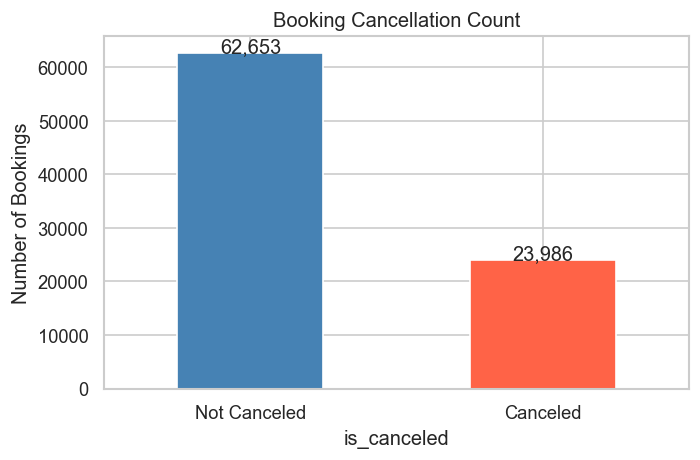

In [4]:
# Cancellation count plot
fig, ax = plt.subplots(figsize=(6, 4))
df['is_canceled'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white', rot=0)
ax.set_xticklabels(['Not Canceled', 'Canceled'])
ax.set_title('Booking Cancellation Count')
ax.set_ylabel('Number of Bookings')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height() + 200), ha='center')
plt.tight_layout()
plt.savefig('01_cancellation_count.png', bbox_inches='tight')
plt.show()

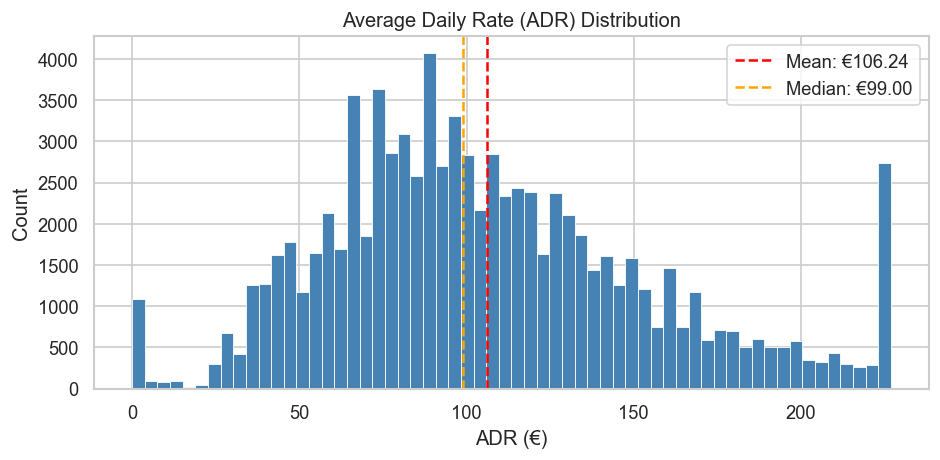

In [5]:
# ADR distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['adr'], bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(df['adr'].mean(), color='red', linestyle='--', label=f'Mean: €{df["adr"].mean():.2f}')
ax.axvline(df['adr'].median(), color='orange', linestyle='--', label=f'Median: €{df["adr"].median():.2f}')
ax.set_title('Average Daily Rate (ADR) Distribution')
ax.set_xlabel('ADR (€)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('02_adr_distribution.png', bbox_inches='tight')
plt.show()

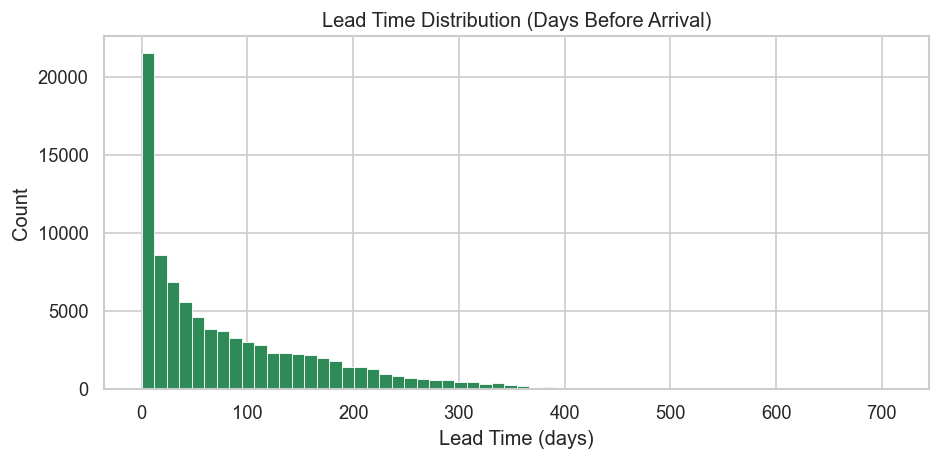

In [6]:
# Lead time distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['lead_time'], bins=60, color='seagreen', edgecolor='white', linewidth=0.5)
ax.set_title('Lead Time Distribution (Days Before Arrival)')
ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('03_lead_time_distribution.png', bbox_inches='tight')
plt.show()

In [7]:
# ── 2. BIVARIATE ANALYSIS ─────────────────────────────────
# Cancellation rate by hotel type
cancel_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
print('Cancellation rate by hotel type:')
print(cancel_hotel)

Cancellation rate by hotel type:
hotel
City Hotel      30.205682
Resort Hotel    23.705203
Name: is_canceled, dtype: float64


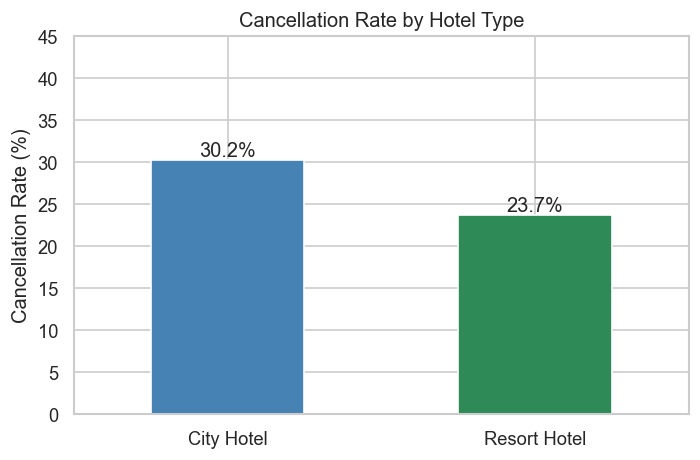

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
cancel_hotel.plot(kind='bar', ax=ax, color=['steelblue', 'seagreen'], edgecolor='white', rot=0)
ax.set_title('Cancellation Rate by Hotel Type')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('')
ax.set_ylim(0, 45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height() + 0.5), ha='center')
plt.tight_layout()
plt.savefig('04_cancel_by_hotel.png', bbox_inches='tight')
plt.show()

Cancellation rate by deposit type:
deposit_type
No Deposit    26.875570
Non Refund    94.701349
Refundable    24.299065
Name: is_canceled, dtype: float64


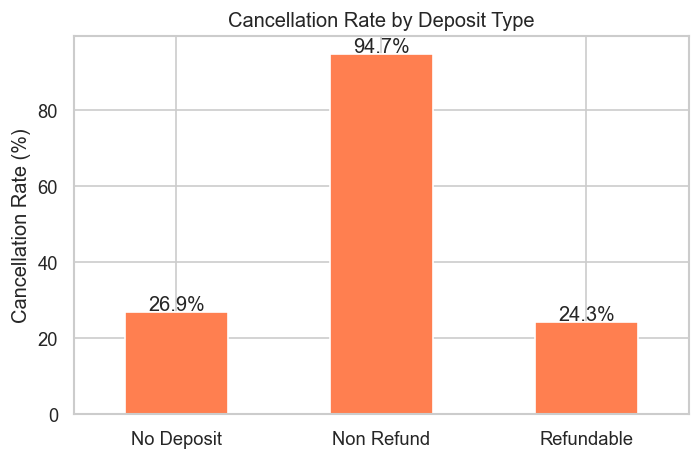

In [9]:
# Cancellation rate by deposit type
cancel_deposit = df.groupby('deposit_type')['is_canceled'].mean() * 100
print('Cancellation rate by deposit type:')
print(cancel_deposit)

fig, ax = plt.subplots(figsize=(6, 4))
cancel_deposit.plot(kind='bar', ax=ax, color='coral', edgecolor='white', rot=0)
ax.set_title('Cancellation Rate by Deposit Type')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height() + 0.5), ha='center')
plt.tight_layout()
plt.savefig('05_cancel_by_deposit.png', bbox_inches='tight')
plt.show()

Cancellation rate by customer type:
customer_type
Contract           16.415518
Group               9.888060
Transient          30.322563
Transient-Party    15.329661
Name: is_canceled, dtype: float64


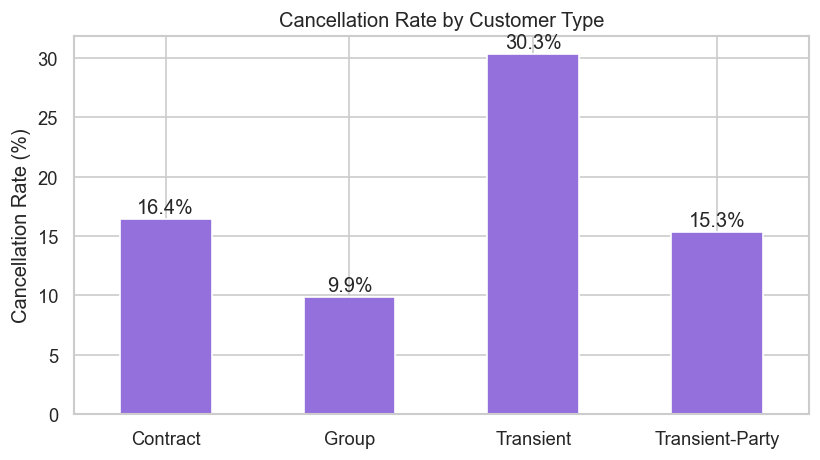

In [10]:
# Cancellation rate by customer type
cancel_customer = df.groupby('customer_type')['is_canceled'].mean() * 100
print('Cancellation rate by customer type:')
print(cancel_customer)

fig, ax = plt.subplots(figsize=(7, 4))
cancel_customer.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white', rot=0)
ax.set_title('Cancellation Rate by Customer Type')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height() + 0.5), ha='center')
plt.tight_layout()
plt.savefig('06_cancel_by_customer_type.png', bbox_inches='tight')
plt.show()

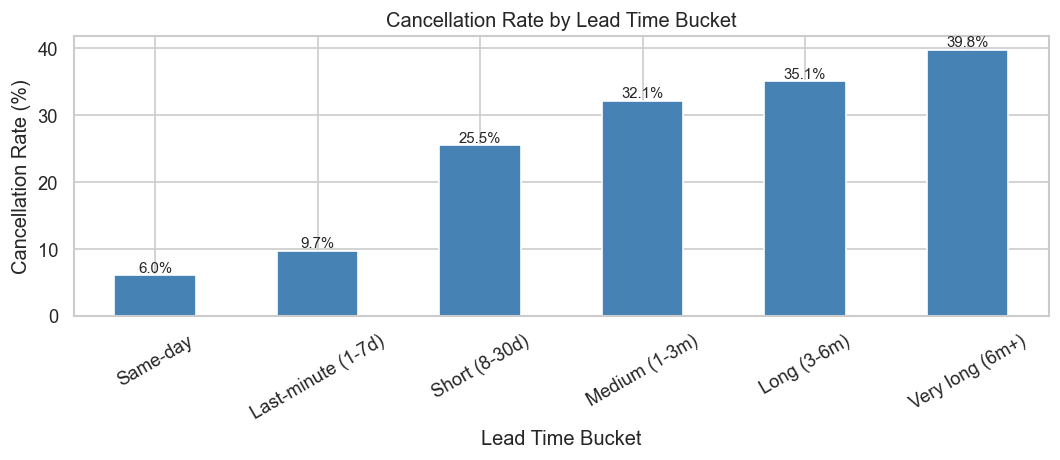

In [11]:
# Cancellation rate by lead time bucket
lt_order = ['Same-day', 'Last-minute (1-7d)', 'Short (8-30d)', 'Medium (1-3m)', 'Long (3-6m)', 'Very long (6m+)']
cancel_lt = df.groupby('lead_time_bucket')['is_canceled'].mean() * 100
cancel_lt = cancel_lt.reindex(lt_order)

fig, ax = plt.subplots(figsize=(9, 4))
cancel_lt.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', rot=30)
ax.set_title('Cancellation Rate by Lead Time Bucket')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('Lead Time Bucket')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height() + 0.5), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('07_cancel_by_lead_time.png', bbox_inches='tight')
plt.show()

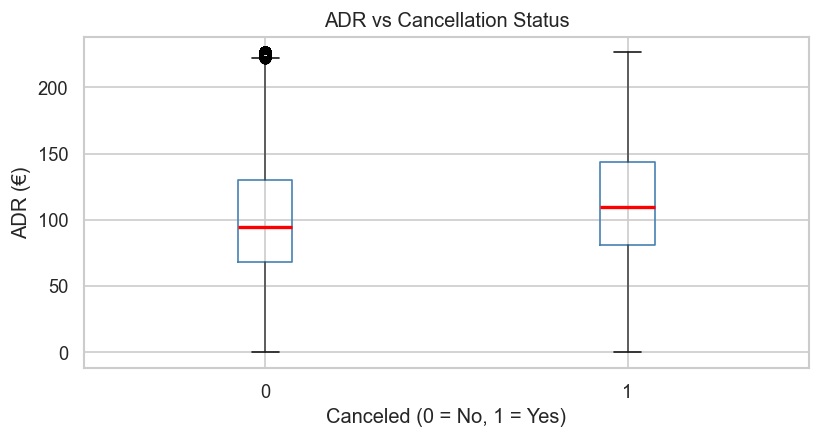

In [12]:
# ADR vs Cancellation — box plot
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column='adr', by='is_canceled', ax=ax, 
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('ADR vs Cancellation Status')
ax.set_xlabel('Canceled (0 = No, 1 = Yes)')
ax.set_ylabel('ADR (€)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('08_adr_vs_cancellation.png', bbox_inches='tight')
plt.show()

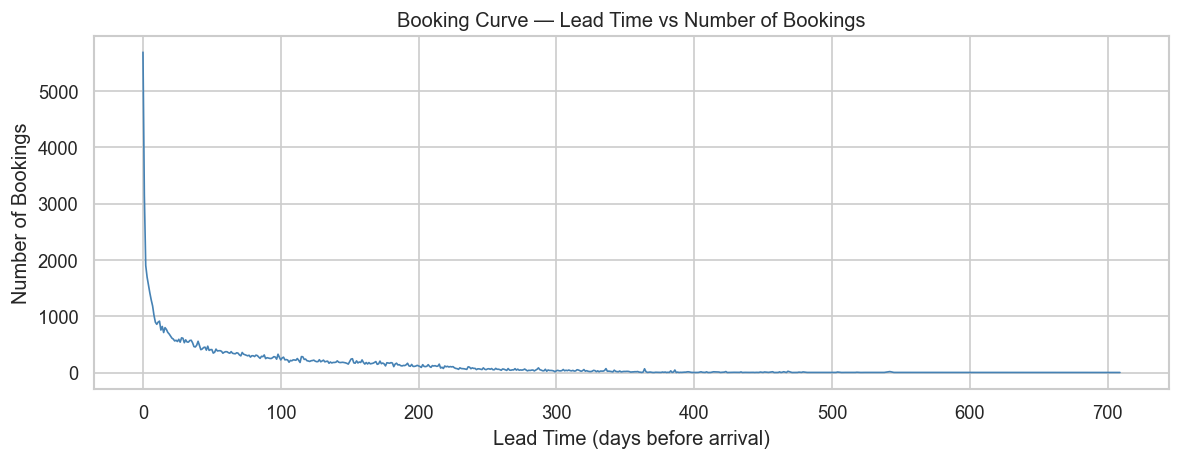

In [13]:
# ── 3. BOOKING CURVE ──────────────────────────────────────
# Lead time vs number of bookings (booking curve)
booking_curve = df.groupby('lead_time').size().reset_index(name='bookings')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(booking_curve['lead_time'], booking_curve['bookings'], color='steelblue', linewidth=1)
ax.set_title('Booking Curve — Lead Time vs Number of Bookings')
ax.set_xlabel('Lead Time (days before arrival)')
ax.set_ylabel('Number of Bookings')
plt.tight_layout()
plt.savefig('09_booking_curve.png', bbox_inches='tight')
plt.show()

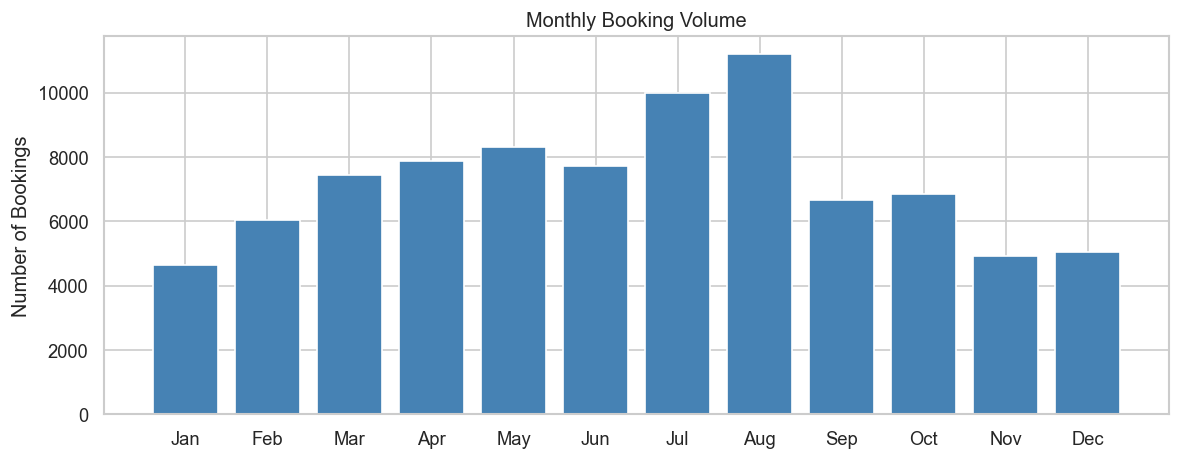

In [14]:
# ── 4. SEASONAL ANALYSIS ──────────────────────────────────
# Monthly booking volume
monthly = df.groupby('arrival_date_month_num').size().reset_index(name='bookings')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly['arrival_date_month_num'], monthly['bookings'], color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Monthly Booking Volume')
ax.set_ylabel('Number of Bookings')
plt.tight_layout()
plt.savefig('10_monthly_booking_volume.png', bbox_inches='tight')
plt.show()

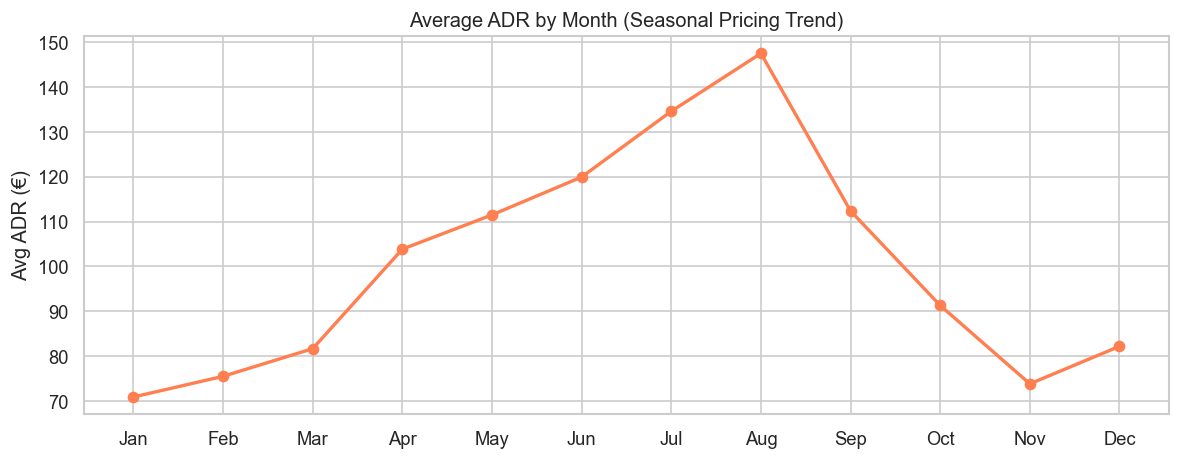

In [15]:
# Monthly Average ADR
monthly_adr = df.groupby('arrival_date_month_num')['adr'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_adr.index, monthly_adr.values, marker='o', color='coral', linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Average ADR by Month (Seasonal Pricing Trend)')
ax.set_ylabel('Avg ADR (€)')
plt.tight_layout()
plt.savefig('11_monthly_adr.png', bbox_inches='tight')
plt.show()

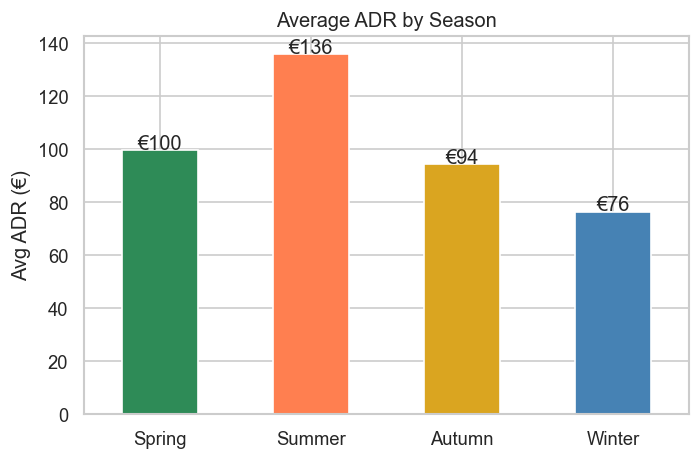

In [16]:
# ADR by season
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_adr = df.groupby('season')['adr'].mean().reindex(season_order)

fig, ax = plt.subplots(figsize=(6, 4))
season_adr.plot(kind='bar', ax=ax, color=['seagreen','coral','goldenrod','steelblue'], edgecolor='white', rot=0)
ax.set_title('Average ADR by Season')
ax.set_ylabel('Avg ADR (€)')
ax.set_xlabel('')
for p in ax.patches:
    ax.annotate(f'€{p.get_height():.0f}', (p.get_x() + p.get_width()/2, p.get_height() + 0.5), ha='center')
plt.tight_layout()
plt.savefig('12_adr_by_season.png', bbox_inches='tight')
plt.show()

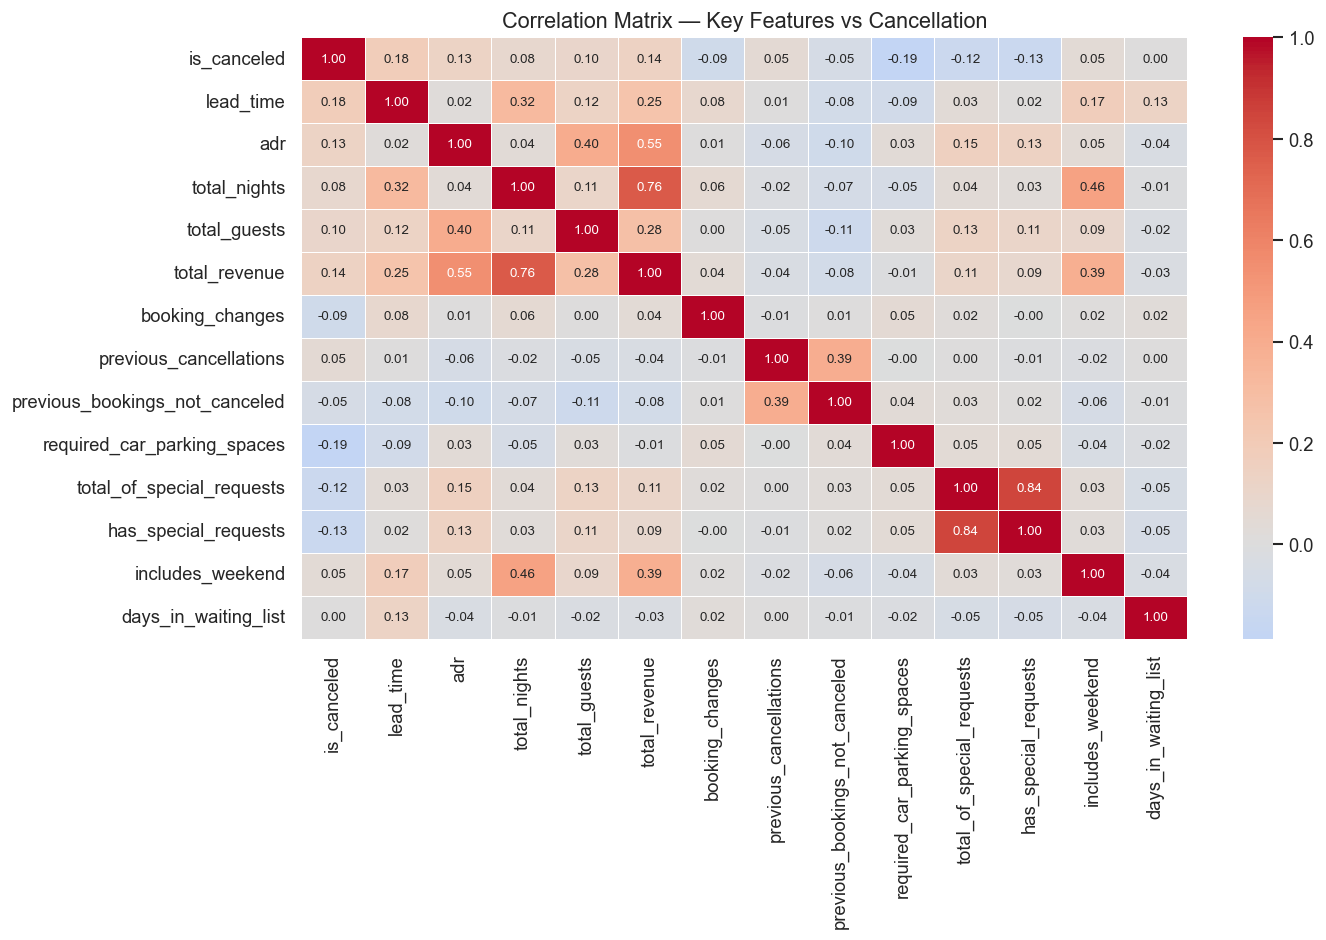

In [17]:
# ── 5. CORRELATION MATRIX ─────────────────────────────────
# Select numeric columns relevant to cancellation
corr_cols = [
    'is_canceled', 'lead_time', 'adr', 'total_nights',
    'total_guests', 'total_revenue', 'booking_changes',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'required_car_parking_spaces', 'total_of_special_requests',
    'has_special_requests', 'includes_weekend', 'days_in_waiting_list'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Key Features vs Cancellation', fontsize=13)
plt.tight_layout()
plt.savefig('13_correlation_matrix.png', bbox_inches='tight')
plt.show()

In [18]:
# Top features correlated with cancellation
cancel_corr = corr_matrix['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)
print('Top features correlated with cancellation:')
print(cancel_corr)

Top features correlated with cancellation:
required_car_parking_spaces      -0.185663
lead_time                         0.183495
total_revenue                     0.136995
adr                               0.131082
has_special_requests             -0.130196
total_of_special_requests        -0.122079
total_guests                      0.098571
booking_changes                  -0.093541
total_nights                      0.081272
previous_bookings_not_canceled   -0.052393
previous_cancellations            0.051371
includes_weekend                  0.047022
days_in_waiting_list              0.004520
Name: is_canceled, dtype: float64


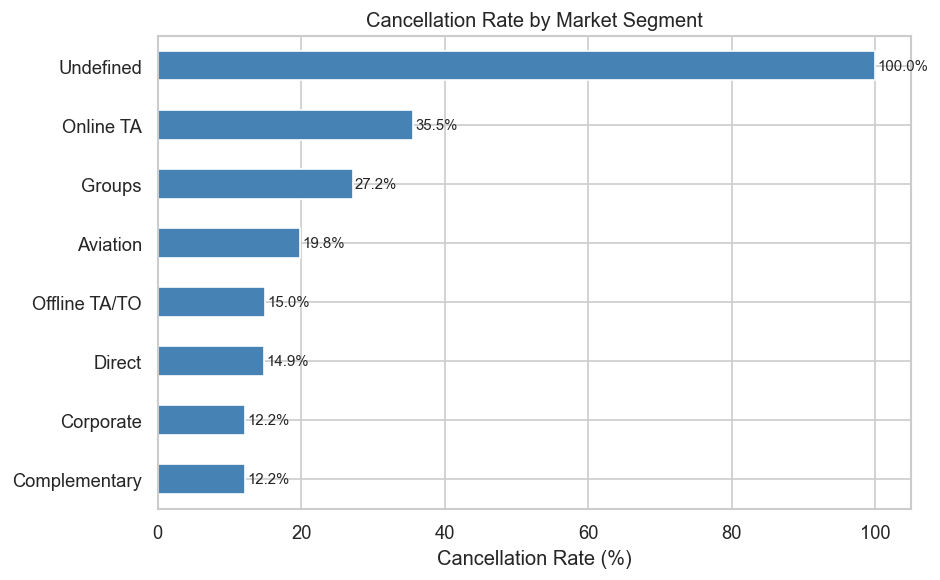

In [19]:
# ── 6. MARKET SEGMENT ANALYSIS ────────────────────────────
segment_cancel = df.groupby('market_segment')['is_canceled'].mean() * 100
segment_cancel = segment_cancel.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
segment_cancel.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Cancellation Rate by Market Segment')
ax.set_xlabel('Cancellation Rate (%)')
ax.set_ylabel('')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', (p.get_width() + 0.3, p.get_y() + p.get_height()/2), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('14_cancel_by_segment.png', bbox_inches='tight')
plt.show()

In [20]:
# ── 7. EDA SUMMARY ────────────────────────────────────────
print('=' * 50)
print('EDA SUMMARY')
print('=' * 50)
print(f"Overall Cancellation Rate:       {df['is_canceled'].mean()*100:.1f}%")
print(f"City Hotel Cancellation Rate:    {df[df['hotel']=='City Hotel']['is_canceled'].mean()*100:.1f}%")
print(f"Resort Hotel Cancellation Rate:  {df[df['hotel']=='Resort Hotel']['is_canceled'].mean()*100:.1f}%")
print(f"Avg ADR:                         €{df['adr'].mean():.2f}")
print(f"Peak Month (bookings):           {df.groupby('arrival_date_month_num').size().idxmax()}")
print(f"Peak Month (ADR):                {df.groupby('arrival_date_month_num')['adr'].mean().idxmax()}")
print(f"Top cancellation driver:         {cancel_corr.index[0]} (corr: {cancel_corr.iloc[0]:.2f})")
print(f"Highest cancel segment:          {segment_cancel.idxmax()} ({segment_cancel.max():.1f}%)")

EDA SUMMARY
Overall Cancellation Rate:       27.7%
City Hotel Cancellation Rate:    30.2%
Resort Hotel Cancellation Rate:  23.7%
Avg ADR:                         €106.24
Peak Month (bookings):           8
Peak Month (ADR):                8
Top cancellation driver:         required_car_parking_spaces (corr: -0.19)
Highest cancel segment:          Undefined (100.0%)
